# 01 - Preprocess Pipeline (Local)
Notebook nay chay preprocessing deepfake tren may local, khong phu thuoc Colab.

## Cell 1 - Setup & Imports

In [2]:
# Muc dich: Cai dat thu vien can thiet va import toan bo module can dung.
%pip install mediapipe opencv-python-headless tqdm pyyaml pandas matplotlib

import platform
import random
import sys
from pathlib import Path

import cv2
import mediapipe as mp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
try:
    import torch
except Exception:
    torch = None
import yaml
from IPython.display import display
from tqdm.auto import tqdm

import os

# Uu tien root tuong minh de tranh sai cwd khi chay VS Code SSH Remote.
_SERVER_ROOT = Path('/root/deepfake_detector')
_LOCAL_ROOT = Path('d:/Study/Code/Python/deepfake_detector')

if _SERVER_ROOT.exists():
    PROJECT_ROOT = _SERVER_ROOT          # Server Ubuntu
elif _LOCAL_ROOT.exists():
    PROJECT_ROOT = _LOCAL_ROOT           # May Windows local
else:
    # Fallback: tu detect nhu cu
    PROJECT_ROOT = Path.cwd()
    if not (PROJECT_ROOT / 'configs').exists() and (PROJECT_ROOT.parent / 'configs').exists():
        PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from preprocess.face_detector import FaceDetector
from preprocess.preprocess import run_preprocess_pipeline, setup_logger
from preprocess.video_utils import list_video_files

# Chinh duong dan cho may local cua ban.
input_candidates = [PROJECT_ROOT / 'raw_videos', PROJECT_ROOT / 'dataset']
INPUT_DIR = next((p for p in input_candidates if p.exists()), input_candidates[0])
OUTPUT_DIR = PROJECT_ROOT / 'processed_faces'
AUG_CONFIG_PATH = PROJECT_ROOT / 'configs' / 'aug_config.yaml'

SAMPLES_PER_VIDEO = 10
TARGET_SIZE = 256

print('PROJECT_ROOT =', PROJECT_ROOT)
print('INPUT_DIR    =', INPUT_DIR)
print('OUTPUT_DIR   =', OUTPUT_DIR)


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


PROJECT_ROOT = d:\Study\Code\Python\deepfake_detector
INPUT_DIR    = d:\Study\Code\Python\deepfake_detector\dataset
OUTPUT_DIR   = d:\Study\Code\Python\deepfake_detector\processed_faces


c:\Users\Heikapu\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Cell 2 - Kiem Tra Moi Truong

In [3]:
# Muc dich: In thong tin he thong, phien ban thu vien va thong ke so video dau vao.
print('Python     :', platform.python_version())
print('OpenCV     :', cv2.__version__)
print('MediaPipe  :', mp.__version__)

try:
    import torch as _torch
except Exception:
    _torch = None

if _torch is None:
    print('CUDA avail : torch not installed')
    print('GPU name   : None (preprocess van chu yeu CPU)')
else:
    gpu_available = bool(_torch.cuda.is_available())
    print('CUDA avail :', gpu_available)
    if gpu_available:
        print('GPU name   :', _torch.cuda.get_device_name(0))
    else:
        print('GPU name   : None (preprocess van chu yeu CPU)')

real_dir = INPUT_DIR / 'Real'
fake_dir = INPUT_DIR / 'Fake'
real_videos = list_video_files(real_dir) if real_dir.exists() else []
fake_videos = list_video_files(fake_dir) if fake_dir.exists() else []

env_df = pd.DataFrame(
    [
        {'label': 'Real', 'num_videos': len(real_videos), 'dir': str(real_dir)},
        {'label': 'Fake', 'num_videos': len(fake_videos), 'dir': str(fake_dir)},
    ]
)
display(env_df)
print('Tong so video:', len(real_videos) + len(fake_videos))


Python     : 3.10.11
OpenCV     : 4.13.0
MediaPipe  : 0.10.33
CUDA avail : False
GPU name   : None (preprocess van chu yeu CPU)


,label,num_videos,dir
0,Real,0,d:\Study\Code\Python\deepfake_detector\dataset...
1,Fake,0,d:\Study\Code\Python\deepfake_detector\dataset...


Tong so video: 0


## Cell 3 - Load Config Augmentation

In [4]:
# Muc dich: Load aug_config.yaml va hien thi toan bo tham so dang bang de kiem tra nhanh.
with open(AUG_CONFIG_PATH, 'r', encoding='utf-8') as f:
    aug_cfg = yaml.safe_load(f)

def _flatten_dict(d, parent=''):
    rows = []
    for k, v in d.items():
        full_k = f'{parent}.{k}' if parent else str(k)
        if isinstance(v, dict):
            rows.extend(_flatten_dict(v, full_k))
        else:
            rows.append({'param': full_k, 'value': v})
    return rows

cfg_df = pd.DataFrame(_flatten_dict(aug_cfg)).sort_values('param').reset_index(drop=True)
display(cfg_df)

crop_margin = float(aug_cfg.get('preprocess', {}).get('crop_margin', 0.3))
MIN_FACE_CONFIDENCE = float(aug_cfg.get('preprocess', {}).get('min_face_confidence', 0.6))
TARGET_SIZE = int(aug_cfg.get('preprocess', {}).get('target_size', TARGET_SIZE))
print('crop_margin =', crop_margin)
print('min_face_confidence =', MIN_FACE_CONFIDENCE)
print('target_size =', TARGET_SIZE)


,param,value
0,augmentation.coarse_dropout.max_height,32
1,augmentation.coarse_dropout.max_holes,4
2,augmentation.coarse_dropout.max_width,32
3,augmentation.coarse_dropout.p,0.2
4,augmentation.color_jitter.brightness,0.15
5,augmentation.color_jitter.contrast,0.15
6,augmentation.color_jitter.hue,0.0
7,augmentation.color_jitter.p,0.8
8,augmentation.color_jitter.saturation,0.1
9,augmentation.gaussian_blur.blur_limit,"[3, 7]"


crop_margin = 0.3
min_face_confidence = 0.6
target_size = 256


## Cell 4 - Test FaceDetector Tren 1 Video

In [1]:
# Muc dich: Thu detect + align_and_crop tren 1 video va visualize ket qua.
# Ban cu chi doc frame dau tien nen de rot truong hop frame dau khong co mat.
# Ban moi: quet nhieu frame tren nhieu video + fallback confidence de tim frame co mat.
all_videos = []
for lbl in ['Real', 'Fake']:
    lbl_dir = INPUT_DIR / lbl
    if lbl_dir.exists():
        all_videos.extend(list_video_files(lbl_dir))

if len(all_videos) == 0:
    raise RuntimeError(f'Khong tim thay video trong {INPUT_DIR}.')

random.shuffle(all_videos)
videos_to_try = all_videos[: min(10, len(all_videos))]

model_path = PROJECT_ROOT / 'preprocess' / 'models' / 'blaze_face_short_range.tflite'
min_face_confidence = (
    float(aug_cfg.get('preprocess', {}).get('min_face_confidence', 0.6))
    if 'aug_cfg' in globals() else 0.6
)
confidence_candidates = [min_face_confidence, 0.5, 0.4, 0.3]

conf_list = []
for c in confidence_candidates:
    c = float(c)
    if 0.0 < c <= 1.0 and c not in conf_list:
        conf_list.append(c)

selected_video = None
selected_frame_bgr = None
selected_detection = None
selected_frame_idx = None
selected_conf = None
detector = None

for sample_video in videos_to_try:
    cap = cv2.VideoCapture(str(sample_video))
    if not cap.isOpened():
        cap.release()
        continue

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total_frames <= 0:
        cap.release()
        continue

    probe_count = min(32, max(8, total_frames))
    probe_indices = np.linspace(0, total_frames - 1, num=probe_count).round().astype(np.int64).tolist()

    for min_conf in conf_list:
        candidate = FaceDetector(model_path=model_path, min_detection_confidence=min_conf)
        found = False
        for frame_idx in probe_indices:
            cap.set(cv2.CAP_PROP_POS_FRAMES, int(frame_idx))
            ok, frame_bgr = cap.read()
            if not ok or frame_bgr is None:
                continue
            detection = candidate.detect(cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB))
            if detection is None:
                continue

            selected_video = sample_video
            selected_frame_bgr = frame_bgr
            selected_detection = detection
            selected_frame_idx = int(frame_idx)
            selected_conf = float(min_conf)
            detector = candidate
            found = True
            break

        if found:
            break
        candidate.close()

    cap.release()
    if selected_detection is not None:
        break

if selected_detection is None or selected_frame_bgr is None or detector is None or selected_video is None:
    raise RuntimeError(
        'Da thu nhieu video/frame nhung chua detect duoc mat. '
        'Thu giam min_face_confidence trong configs/aug_config.yaml (vd 0.3) '
        'hoac kiem tra lai chat luong du lieu video.'
    )

print(f'Selected video   : {selected_video.name}')
print(f'Selected frame   : {selected_frame_idx}')
print(f'Used confidence  : {selected_conf:.2f}')

vis_bgr = detector.visualize_detection(selected_frame_bgr, selected_detection)
crop_bgr = detector.align_and_crop(
    bgr_frame=selected_frame_bgr,
    detection=selected_detection,
    target_size=(TARGET_SIZE, TARGET_SIZE),
    crop_margin=crop_margin,
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(cv2.cvtColor(vis_bgr, cv2.COLOR_BGR2RGB))
axes[0].set_title(f'Frame goc + detection\\n{selected_video.name} | idx={selected_frame_idx}')
axes[0].axis('off')

if crop_bgr is not None:
    axes[1].imshow(cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2RGB))
    axes[1].set_title('Face da align + crop')
else:
    axes[1].imshow(np.zeros((TARGET_SIZE, TARGET_SIZE, 3), dtype=np.uint8))
    axes[1].set_title('Co detect nhung crop that bai')
axes[1].axis('off')

plt.tight_layout()
plt.show()
detector.close()


NameError: name 'INPUT_DIR' is not defined

## Cell 5 - Chay Preprocessing Chinh (Train/Val/Test)


In [ ]:
# Muc dich: Chay preprocess cho train/val/test (neu co), moi split gom Real/Fake.
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def _detect_input_splits(input_root: Path) -> list[str]:
    splits = [s for s in ['train', 'val', 'test'] if (input_root / s).is_dir()]
    if splits:
        return splits
    return ['train']


split_names = _detect_input_splits(INPUT_DIR)
summary_rows = []

for split in split_names:
    split_input_root = INPUT_DIR / split if (INPUT_DIR / split).is_dir() else INPUT_DIR
    split_output_root = OUTPUT_DIR / split
    split_output_root.mkdir(parents=True, exist_ok=True)

    logger = setup_logger(split_output_root / 'preprocess.log')
    labels_to_run = [lbl for lbl in ['Real', 'Fake'] if (split_input_root / lbl).exists()]

    if len(labels_to_run) == 0:
        print(f'[WARN] Bo qua split={split}: khong tim thay folder Real/Fake trong {split_input_root}')
        continue

    print(f'\n=== PREPROCESS split={split} ===')
    for lbl in tqdm(labels_to_run, desc=f'Preprocess {split}'):
        summary = run_preprocess_pipeline(
            input_dir=str(split_input_root / lbl),
            output_dir=str(split_output_root),
            label=lbl,
            samples_per_video=SAMPLES_PER_VIDEO,
            target_size=TARGET_SIZE,
            crop_margin=crop_margin,
            min_face_confidence=MIN_FACE_CONFIDENCE,
            logger=logger,
        )
        summary_rows.append(
            {
                'split': split,
                'label': lbl,
                'success': int(summary.get('success', 0)),
                'error': int(summary.get('error', 0)),
                'skipped': int(summary.get('skipped', 0)),
                'saved_frames': int(summary.get('saved_frames', 0)),
                'miss': int(summary.get('miss', 0)),
                'retry_ok': int(summary.get('retry_ok', 0)),
                'prev_bbox_ok': int(summary.get('prev_bbox_ok', 0)),
            }
        )

if len(summary_rows) == 0:
    raise RuntimeError('Khong preprocess duoc split nao. Kiem tra lai INPUT_DIR.')

summary_df = pd.DataFrame(summary_rows).sort_values(['split', 'label']).reset_index(drop=True)
display(summary_df)

print('\nTong ket theo split:')
split_total_df = (
    summary_df
    .groupby('split', as_index=False)[['success', 'error', 'skipped', 'saved_frames']]
    .sum()
)
display(split_total_df)

print('Log preprocess tung split:')
for split in sorted(summary_df['split'].unique()):
    print(f'  - {split}:', OUTPUT_DIR / split / 'preprocess.log')


## Cell 6 - Kiem Tra Output Sau Preprocess (Theo split)


,split,real_videos,fake_videos,real_images,fake_images,fake_real_ratio,real_bad_framecount,fake_bad_framecount
0,train,1646,4284,16460,42840,2.602673,0,0
1,val,1758,957,0,9100,inf,1758,47
2,test,1052,3995,0,0,inf,1052,3995



=== SAMPLE split=train ===


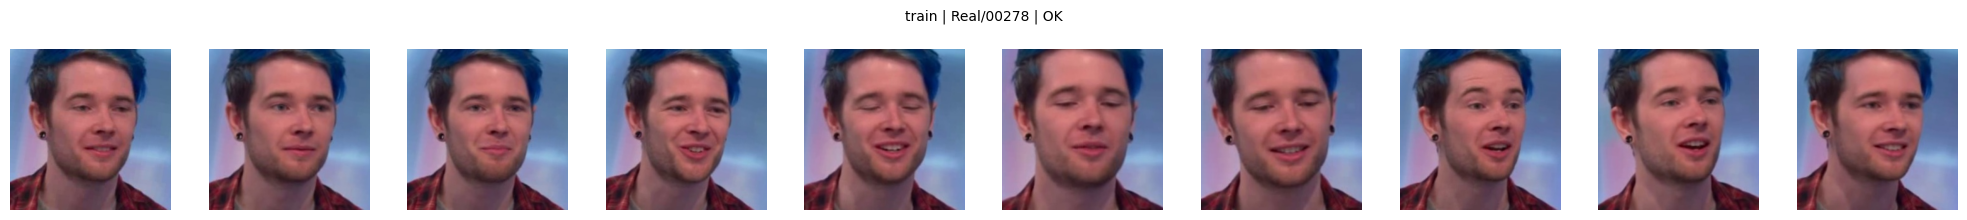

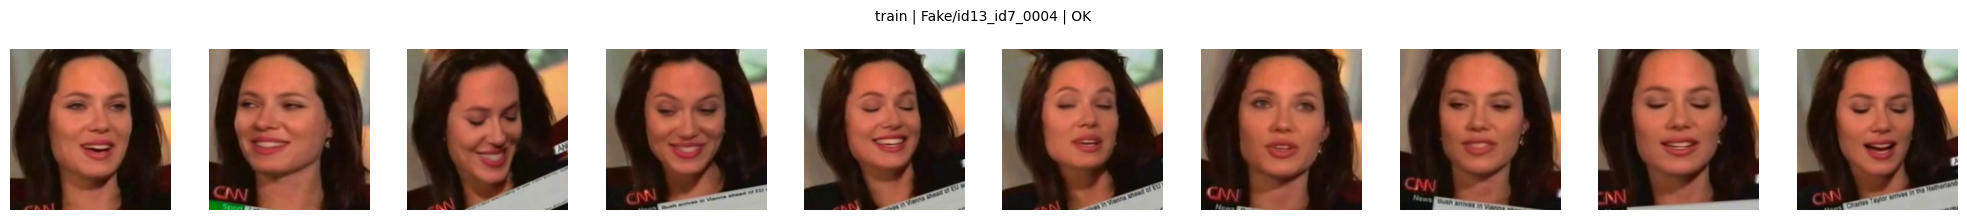


=== SAMPLE split=val ===


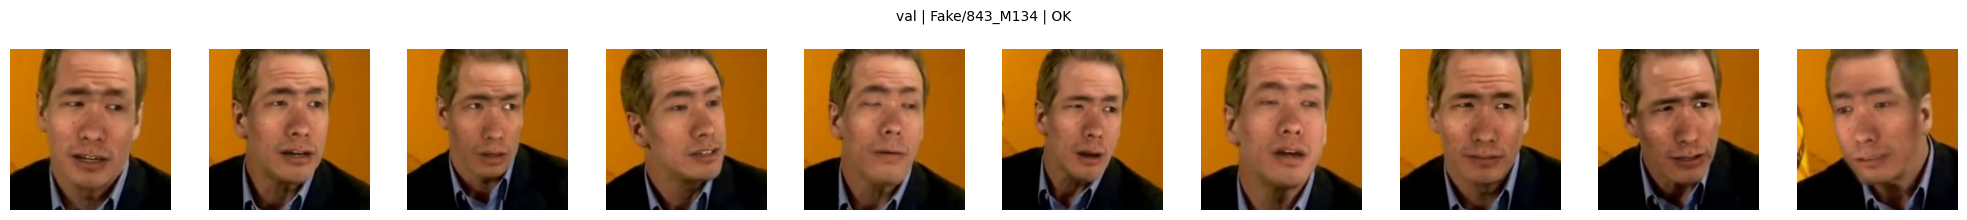

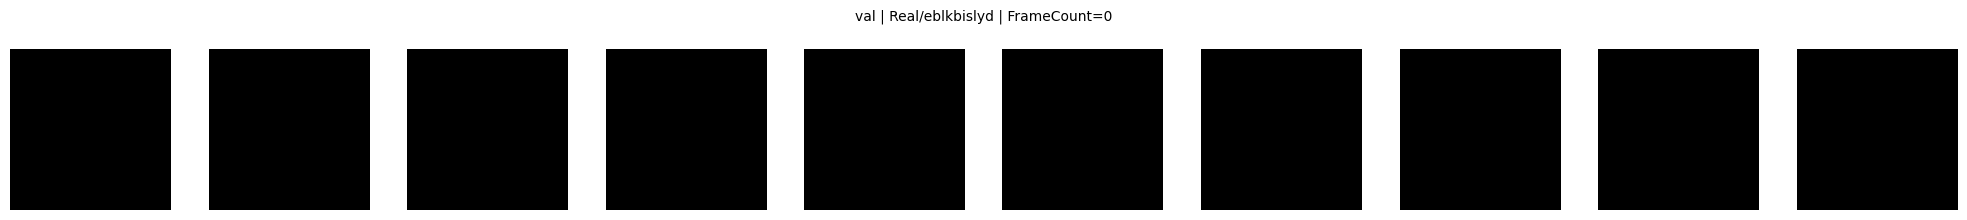


=== SAMPLE split=test ===


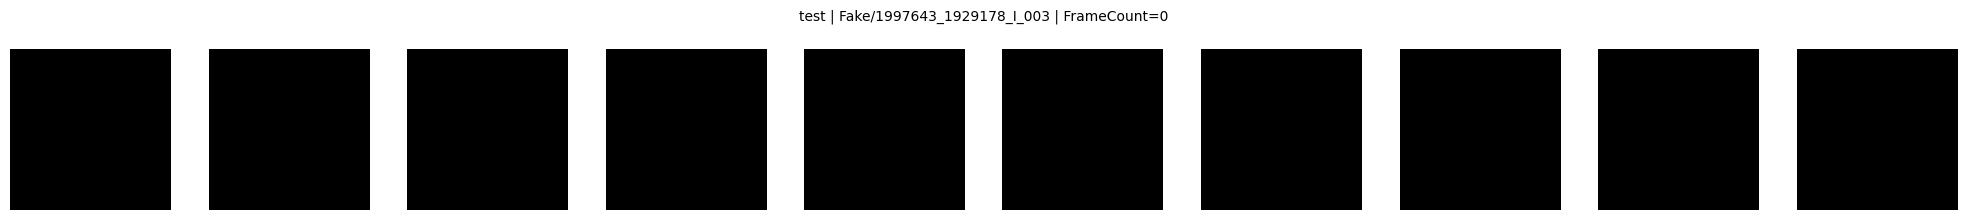

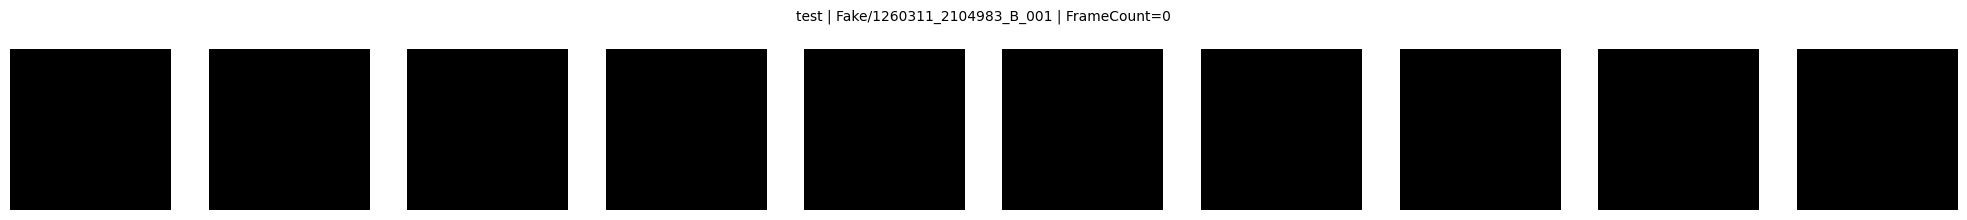

In [5]:
# Muc dich: Kiem tra output theo tung split, verify so frame va thong ke class imbalance.
def _video_dirs_for_label(root_dir, label):
    label_dir = root_dir / label
    if not label_dir.exists():
        return []
    return sorted([p for p in label_dir.iterdir() if p.is_dir()])


def _frame_files(video_dir):
    return sorted(video_dir.glob('*_f*.jpg'))


def _detect_output_splits(output_root: Path) -> list[str]:
    splits = [s for s in ['train', 'val', 'test'] if (output_root / s).is_dir()]
    if splits:
        return splits
    return ['train']


output_splits = _detect_output_splits(OUTPUT_DIR)
stats_rows = []

for split in output_splits:
    split_root = OUTPUT_DIR / split if (OUTPUT_DIR / split).is_dir() else OUTPUT_DIR
    real_video_dirs = _video_dirs_for_label(split_root, 'Real')
    fake_video_dirs = _video_dirs_for_label(split_root, 'Fake')

    real_images = sum(len(_frame_files(v)) for v in real_video_dirs)
    fake_images = sum(len(_frame_files(v)) for v in fake_video_dirs)
    imbalance_ratio = (fake_images / real_images) if real_images > 0 else float('inf')

    bad_real = [v.name for v in real_video_dirs if len(_frame_files(v)) != SAMPLES_PER_VIDEO]
    bad_fake = [v.name for v in fake_video_dirs if len(_frame_files(v)) != SAMPLES_PER_VIDEO]

    stats_rows.append(
        {
            'split': split,
            'real_videos': len(real_video_dirs),
            'fake_videos': len(fake_video_dirs),
            'real_images': real_images,
            'fake_images': fake_images,
            'fake_real_ratio': imbalance_ratio,
            'real_bad_framecount': len(bad_real),
            'fake_bad_framecount': len(bad_fake),
        }
    )

stats_df = pd.DataFrame(stats_rows)
display(stats_df)

# Visualize ngau nhien 2 video moi split (neu co)
for split in output_splits:
    split_root = OUTPUT_DIR / split if (OUTPUT_DIR / split).is_dir() else OUTPUT_DIR
    real_video_dirs = _video_dirs_for_label(split_root, 'Real')
    fake_video_dirs = _video_dirs_for_label(split_root, 'Fake')
    all_video_dirs = real_video_dirs + fake_video_dirs

    if len(all_video_dirs) == 0:
        print(f'[WARN] split={split}: chua co output de visualize.')
        continue

    sample_k = min(2, len(all_video_dirs))
    sample_dirs = random.sample(all_video_dirs, sample_k)

    print(f'\n=== SAMPLE split={split} ===')
    for video_dir in sample_dirs:
        frames = _frame_files(video_dir)
        fig, axes = plt.subplots(1, SAMPLES_PER_VIDEO, figsize=(2 * SAMPLES_PER_VIDEO, 2.2))
        if SAMPLES_PER_VIDEO == 1:
            axes = [axes]

        for i in range(SAMPLES_PER_VIDEO):
            ax = axes[i]
            if i < len(frames):
                img_bgr = cv2.imread(str(frames[i]))
                if img_bgr is not None:
                    ax.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
                else:
                    ax.imshow(np.zeros((TARGET_SIZE, TARGET_SIZE, 3), dtype=np.uint8))
            else:
                ax.imshow(np.zeros((TARGET_SIZE, TARGET_SIZE, 3), dtype=np.uint8))
            ax.axis('off')

        status = 'OK' if len(frames) == SAMPLES_PER_VIDEO else f'FrameCount={len(frames)}'
        fig.suptitle(f'{split} | {video_dir.parent.name}/{video_dir.name} | {status}', fontsize=10)
        plt.tight_layout()
        plt.show()


## Cell 7 - Clean Output Folder (Train/Val/Test)


In [6]:
# Muc dich: Chay clean_processed_dataset.py cho train/val/test va tong hop thong ke loi.
# - train/val: giu 5-tier nhu binh thuong
# - test: chi uu tien Tier 3 (black frame) de mo phong du lieu doi thuc
assert 'OUTPUT_DIR' in dir() and OUTPUT_DIR is not None, \
    "Chua chay Cell 1. Hay chay lai tu Cell 1 (Kernel -> Restart & Run All)."

import re
import subprocess
import sys
from collections import Counter
from pathlib import Path

import pandas as pd

SCRIPT_PATH = PROJECT_ROOT / 'clean_processed_dataset.py'
if not SCRIPT_PATH.exists():
    raise FileNotFoundError(f'Khong tim thay script: {SCRIPT_PATH}')

DELETE_MODE = False        # doi thanh True de xoa that
BAD_RATIO = 0.5
BLACK_THRESHOLD = 10.0
STD_THRESHOLD = 5.0
BLUR_THRESHOLD = 15.0      # train/val


def _detect_output_splits(output_root: Path) -> list[str]:
    splits = [s for s in ['train', 'val', 'test'] if (output_root / s).is_dir()]
    if splits:
        return splits
    return ['train']


def _extract_metrics_from_output(text: str) -> dict:
    def _pick_int(pattern: str) -> int | None:
        m = re.search(pattern, text, flags=re.IGNORECASE)
        return int(m.group(1)) if m else None

    reason_counts = Counter()
    in_reason_block = False
    for raw_line in text.splitlines():
        line = raw_line.strip()
        if not line and in_reason_block:
            in_reason_block = False
            continue
        if 'Phan loai loi' in line:
            in_reason_block = True
            continue
        if in_reason_block:
            m = re.match(r'(.+?)\s*:\s*(\d+)\s+folders?$', line)
            if m:
                reason_counts[m.group(1).strip()] += int(m.group(2))

    return {
        'total_folders': _pick_int(r'Tong so folders\s*:\s*(\d+)'),
        'ok_folders': _pick_int(r'Hop le\s*\(OK\)\s*:\s*(\d+)'),
        'error_folders': _pick_int(r'Can xoa\s*\(loi\)\s*:\s*(\d+)'),
        'deleted_success': _pick_int(r'Ket qua xoa\s*:\s*thanh cong\s*=\s*(\d+)'),
        'deleted_failed': _pick_int(r'Ket qua xoa\s*:\s*thanh cong\s*=\s*\d+\s*,\s*that bai\s*=\s*(\d+)'),
        'reason_counts': reason_counts,
    }


output_splits = _detect_output_splits(OUTPUT_DIR)
if len(output_splits) == 0:
    raise RuntimeError('Khong tim thay split output nao de clean.')

summary_rows = []
reason_total = Counter()

for split in output_splits:
    split_output_dir = OUTPUT_DIR / split if (OUTPUT_DIR / split).is_dir() else OUTPUT_DIR

    # Test: chi ap dung Tier 3 (black frame)
    # - Tier 4/5 tat bang threshold = 0
    # - Tier 2 giam toi thieu = 1 de tranh loai bo qua nhieu video test
    if split == 'test':
        min_frames = 1
        std_threshold = 0.0
        blur_threshold = 0.0
    else:
        min_frames = SAMPLES_PER_VIDEO
        std_threshold = STD_THRESHOLD
        blur_threshold = BLUR_THRESHOLD

    cmd = [
        sys.executable, str(SCRIPT_PATH),
        '--output-dir', str(split_output_dir),
        '--min-frames', str(min_frames),
        '--bad-ratio', str(BAD_RATIO),
        '--threshold', str(BLACK_THRESHOLD),
        '--std-threshold', str(std_threshold),
        '--blur-threshold', str(blur_threshold),
    ]
    if DELETE_MODE:
        cmd.append('--delete')

    print(f'\n=== CLEAN split={split} ===')
    print('Running:', ' '.join(cmd))
    result = subprocess.run(
        cmd,
        capture_output=True,
        text=True,
        encoding='utf-8',
        errors='replace',
    )

    combined_output = ((result.stdout or '') + '\n' + (result.stderr or '')).strip()
    if combined_output:
        print(combined_output)
    else:
        print('[WARN] Split nay khong tra ve log nao.')

    if result.returncode != 0:
        raise RuntimeError(f'Cleanup split={split} failed with code {result.returncode}')

    metrics = _extract_metrics_from_output(combined_output)
    reason_total.update(metrics['reason_counts'])
    summary_rows.append({
        'split': split,
        'total_folders': metrics['total_folders'],
        'ok_folders': metrics['ok_folders'],
        'error_folders': metrics['error_folders'],
        'deleted_success': metrics['deleted_success'] if DELETE_MODE else None,
        'deleted_failed': metrics['deleted_failed'] if DELETE_MODE else None,
    })

summary_df = pd.DataFrame(summary_rows).sort_values('split').reset_index(drop=True)

print('\n=== TONG HOP CLEAN THEO SPLIT ===')
display(summary_df)

for col in ['total_folders', 'ok_folders', 'error_folders', 'deleted_success', 'deleted_failed']:
    summary_df[col] = pd.to_numeric(summary_df[col], errors='coerce')

total_folders = int(summary_df['total_folders'].sum()) if summary_df['total_folders'].notna().any() else 0
ok_folders = int(summary_df['ok_folders'].sum()) if summary_df['ok_folders'].notna().any() else 0
error_folders = int(summary_df['error_folders'].sum()) if summary_df['error_folders'].notna().any() else 0

print(f'Tong 3 tap (train/val/test): total={total_folders}, ok={ok_folders}, loi={error_folders}')
if DELETE_MODE:
    deleted_success = int(summary_df['deleted_success'].sum()) if summary_df['deleted_success'].notna().any() else 0
    deleted_failed = int(summary_df['deleted_failed'].sum()) if summary_df['deleted_failed'].notna().any() else 0
    print(f'Tong ket xoa that su: thanh cong={deleted_success}, that bai={deleted_failed}')

if len(reason_total) > 0:
    reason_df = (
        pd.DataFrame([{'reason': k, 'folders': v} for k, v in reason_total.items()])
        .sort_values('folders', ascending=False)
        .reset_index(drop=True)
    )
    print('\nTop ly do loi (gop 3 tap):')
    display(reason_df)
else:
    print('Khong parse duoc chi tiet ly do loi tu log (nhung van da co bang tong hop neu script co in).')



=== CLEAN split=train ===
Running: c:\Users\Heikapu\AppData\Local\Programs\Python\Python310\python.exe d:\Study\Code\Python\deepfake_detector\clean_processed_dataset.py --output-dir d:\Study\Code\Python\deepfake_detector\processed_faces\train --min-frames 10 --bad-ratio 0.5 --threshold 10.0 --std-threshold 5.0 --blur-threshold 15.0
  DEEPFAKE DATASET CLEANER  (5-tier | 50-core optimized)
  Dir     : d:\Study\Code\Python\deepfake_detector\processed_faces\train
  Workers : 16 processes
  Mode    : DRY-RUN (them --delete de xoa that)

  Tier 1  Empty folder     khong co anh
  Tier 2  Too few frames   < 10 frames
  Tier 3  Black frame      mean < 10.0
  Tier 4  Uniform frame    std  < 5.0
  Tier 5  Blurry/NoFace    Laplacian var < 15.0
  Xoa folder neu ty le frame loi > 50%

  Tim thay 5930 folders  (Real=1646, Fake=4284)


  KET QUA QUET
  Tong so folders : 5930
  Hop le (OK)     : 5930
  Can xoa (loi)   : 0

  [OK] Dataset sach! Khong co folder nao can xoa.



Scanning: 100%|███████████

,split,total_folders,ok_folders,error_folders,deleted_success,deleted_failed
0,test,5047,5047,0,None,None
1,train,5930,5930,0,None,None
2,val,2715,2715,0,None,None


Tong 3 tap (train/val/test): total=13692, ok=13692, loi=0
Khong parse duoc chi tiet ly do loi tu log (nhung van da co bang tong hop neu script co in).
